# Tarefa: Segmentação de Clientes — Mall Customer Segmentation

**Aluno:** Cauê Reis

**Disciplina:** Aprendizado de Máquina Não Supervisionado

## Dataset Mall Customers — Análise de Clusters com Algoritmos Hierárquico, DBSCAN, HDBSCAN e Spectral Clustering

**Objetivo:** Identificar perfis distintos de consumidores em um shopping center com base em idade, renda anual e pontuação de gastos. Aplica-se e compara-se quatro algoritmos de agrupamento não supervisionado — Clustering Hierárquico, DBSCAN, HDBSCAN e Spectral Clustering — selecionando o modelo de melhor desempenho para interpretação de negócio.

### 1. Importação das Bibliotecas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import hdbscan

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'

### 2. Carregamento dos Dados

In [4]:
df = pd.read_csv('Mall_Customers.csv')

print('Primeiras observacoes do dataset:')
display(df.head(10))

print(f'\nDimensoes: {df.shape[0]} amostras x {df.shape[1]} colunas')
print(f'\nTipos de dados:')
print(df.dtypes)
print(f'\nValores nulos:')
print(df.isnull().sum())

Primeiras observacoes do dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Dimensoes: 200 amostras x 5 colunas

Tipos de dados:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Valores nulos:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


### 3. Análise Exploratória dos Dados

In [5]:
display(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe().round(3))

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000,200.000,200.000
mean,38.850,60.560,50.200
std,13.969,26.265,25.824
min,18.000,15.000,1.000
25%,28.750,41.500,34.750
50%,36.000,61.500,50.000
75%,49.000,78.000,73.000
max,70.000,137.000,99.000


In [6]:
print('Distribuicao por genero:')
print(df['Gender'].value_counts())
print(f"Percentual feminino: {df['Gender'].value_counts(normalize=True)['Female']*100:.1f}%")

Distribuicao por genero:
Gender
Female    112
Male       88
Name: count, dtype: int64
Percentual feminino: 56.0%


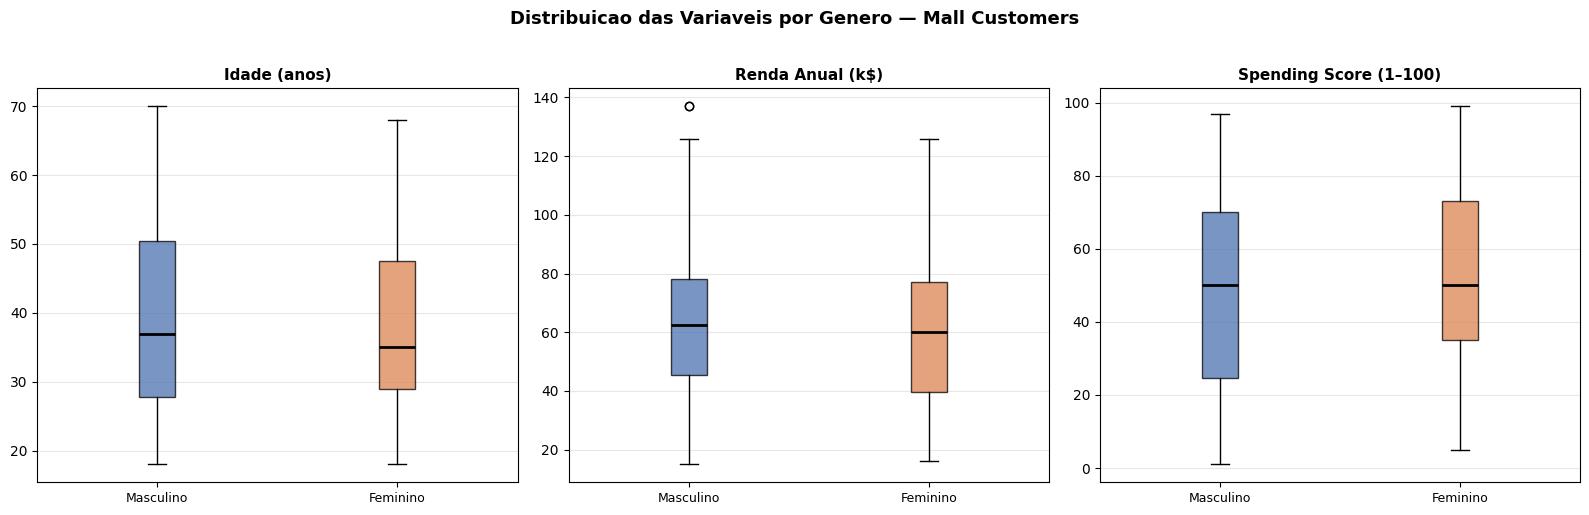

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colunas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
cores   = ['#4C72B0', '#DD8452', '#55A868']
titulos = ['Idade (anos)', 'Renda Anual (k$)', 'Spending Score (1–100)']

for ax, col, cor, titulo in zip(axes, colunas, cores, titulos):
    grupos = [df[df['Gender'] == g][col].values for g in ['Male', 'Female']]
    bp = ax.boxplot(grupos, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Masculino', 'Feminino'], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuicao das Variaveis por Genero — Mall Customers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

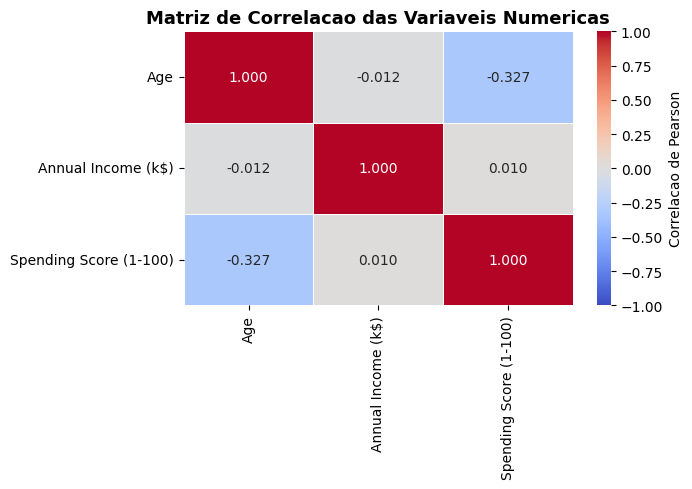

In [8]:
corr_matrix = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlacao de Pearson'}
)
plt.title('Matriz de Correlacao das Variaveis Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

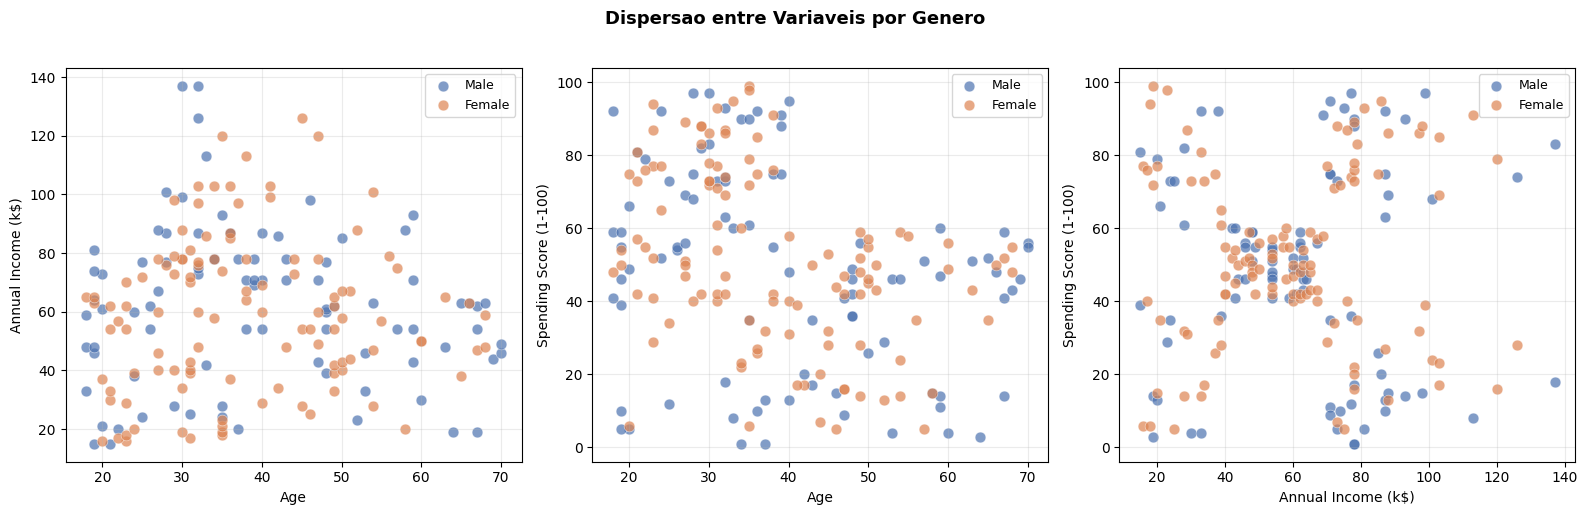

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pares = [
    ('Age', 'Annual Income (k$)'),
    ('Age', 'Spending Score (1-100)'),
    ('Annual Income (k$)', 'Spending Score (1-100)')
]
cores_gen = {'Male': '#4C72B0', 'Female': '#DD8452'}

for ax, (x, y) in zip(axes, pares):
    for gen, cor in cores_gen.items():
        mask = df['Gender'] == gen
        ax.scatter(df.loc[mask, x], df.loc[mask, y],
                   c=cor, label=gen, alpha=0.7, edgecolors='white', linewidths=0.4, s=60)
    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

plt.suptitle('Dispersao entre Variaveis por Genero', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4. Pré-processamento — Seleção de Features e Padronização

In [11]:
# Seleção das features recomendadas pelo dicionario de dados
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# Padronizacao
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Dados originais (primeiras 3 linhas):')
print(pd.DataFrame(X[:3], columns=features).round(3).to_string())
print()
print('Dados padronizados (primeiras 3 linhas):')
print(pd.DataFrame(X_scaled[:3], columns=features).round(3).to_string())
print()
print(f'Media pos-escala (deve ser ~0): {X_scaled.mean(axis=0).round(6)}')
print(f'Desvio pos-escala (deve ser ~1): {X_scaled.std(axis=0).round(6)}')

Dados originais (primeiras 3 linhas):
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6

Dados padronizados (primeiras 3 linhas):
     Age  Annual Income (k$)  Spending Score (1-100)
0 -1.425              -1.739                  -0.435
1 -1.281              -1.739                   1.196
2 -1.353              -1.701                  -1.716

Media pos-escala (deve ser ~0): [-0. -0. -0.]
Desvio pos-escala (deve ser ~1): [1. 1. 1.]


### 5. Modelagem — Comparação entre os Quatro Algoritmos

#### 5.1 Clustering Hierárquico — Escolha do Número de Clusters

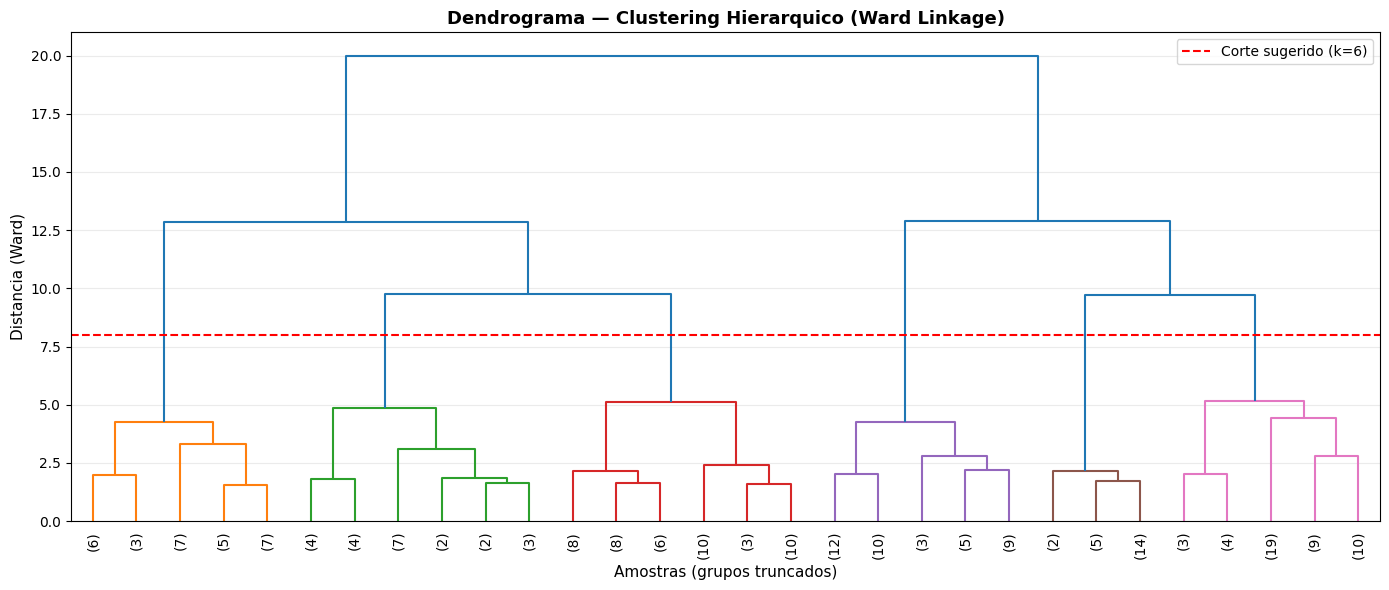

In [12]:
# Dendrograma para apoiar a escolha de k
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10,
           color_threshold=8)
plt.axhline(y=8, color='red', linestyle='--', linewidth=1.5, label='Corte sugerido (k=6)')
plt.title('Dendrograma — Clustering Hierarquico (Ward Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Amostras (grupos truncados)', fontsize=11)
plt.ylabel('Distancia (Ward)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

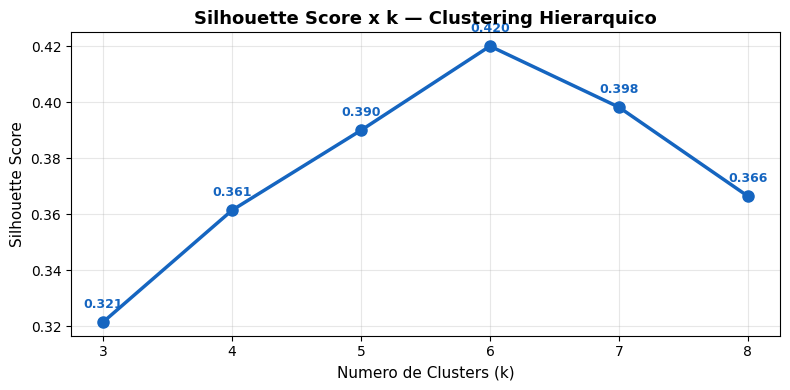

In [13]:
# Silhouette para k = 3 a 8
sil_scores = []
k_range = range(3, 9)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sil_scores, 'o-', color='#1565C0', linewidth=2.5, markersize=8)
for k, s in zip(k_range, sil_scores):
    plt.text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9, fontweight='bold', color='#1565C0')
plt.xlabel('Numero de Clusters (k)', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Silhouette Score x k — Clustering Hierarquico', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Modelo final Hierarquico
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, labels_hc)
db_hc  = davies_bouldin_score(X_scaled, labels_hc)
ch_hc  = calinski_harabasz_score(X_scaled, labels_hc)

print(f'=== Clustering Hierarquico (k=6) ===')
print(f'Silhouette Score       : {sil_hc:.4f}  (quanto maior, melhor)')
print(f'Davies-Bouldin Score   : {db_hc:.4f}   (quanto menor, melhor)')
print(f'Calinski-Harabasz Score: {ch_hc:.1f}  (quanto maior, melhor)')
print()
print('Distribuicao dos clusters:')
print(pd.Series(labels_hc).value_counts().sort_index())

=== Clustering Hierarquico (k=6) ===
Silhouette Score       : 0.4201  (quanto maior, melhor)
Davies-Bouldin Score   : 0.8521   (quanto menor, melhor)
Calinski-Harabasz Score: 128.0  (quanto maior, melhor)

Distribuicao dos clusters:
0    45
1    45
2    39
3    28
4    22
5    21
Name: count, dtype: int64


#### 5.2 DBSCAN

In [16]:
# DBSCAN — melhor configuracao encontrada na busca de hiperparametros
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_db = list(labels_db).count(-1)

sil_db = silhouette_score(X_scaled, labels_db)
db_db  = davies_bouldin_score(X_scaled, labels_db)
ch_db  = calinski_harabasz_score(X_scaled, labels_db)

print(f'=== DBSCAN (eps=0.8, min_samples=5) ===')
print(f'Clusters encontrados   : {n_clusters_db}')
print(f'Pontos de ruido (noise): {noise_db} ({noise_db/len(labels_db)*100:.1f}%)')
print(f'Silhouette Score       : {sil_db:.4f}')
print(f'Davies-Bouldin Score   : {db_db:.4f}')
print(f'Calinski-Harabasz Score: {ch_db:.1f}')

=== DBSCAN (eps=0.8, min_samples=5) ===
Clusters encontrados   : 1
Pontos de ruido (noise): 6 (3.0%)
Silhouette Score       : 0.2544
Davies-Bouldin Score   : 4.2897
Calinski-Harabasz Score: 1.7


#### 5.3 HDBSCAN

In [17]:
import hdbscan

clusterer_hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
labels_hdb = clusterer_hdb.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
noise_hdb = list(labels_hdb).count(-1)

sil_hdb = silhouette_score(X_scaled, labels_hdb)
db_hdb  = davies_bouldin_score(X_scaled, labels_hdb)
ch_hdb  = calinski_harabasz_score(X_scaled, labels_hdb)

print(f'=== HDBSCAN (min_cluster_size=10, min_samples=5) ===')
print(f'Clusters encontrados   : {n_clusters_hdb}')
print(f'Pontos de ruido (noise): {noise_hdb} ({noise_hdb/len(labels_hdb)*100:.1f}%)')
print(f'Silhouette Score       : {sil_hdb:.4f}')
print(f'Davies-Bouldin Score   : {db_hdb:.4f}')
print(f'Calinski-Harabasz Score: {ch_hdb:.1f}')

=== HDBSCAN (min_cluster_size=10, min_samples=5) ===
Clusters encontrados   : 4
Pontos de ruido (noise): 78 (39.0%)
Silhouette Score       : 0.2303
Davies-Bouldin Score   : 1.4552
Calinski-Harabasz Score: 40.2


#### 5.4 Spectral Clustering

In [18]:
spectral = SpectralClustering(n_clusters=6, random_state=42, affinity='rbf', n_neighbors=10)
labels_sp = spectral.fit_predict(X_scaled)

sil_sp = silhouette_score(X_scaled, labels_sp)
db_sp  = davies_bouldin_score(X_scaled, labels_sp)
ch_sp  = calinski_harabasz_score(X_scaled, labels_sp)

print(f'=== Spectral Clustering (k=6) ===')
print(f'Silhouette Score       : {sil_sp:.4f}')
print(f'Davies-Bouldin Score   : {db_sp:.4f}')
print(f'Calinski-Harabasz Score: {ch_sp:.1f}')

=== Spectral Clustering (k=6) ===
Silhouette Score       : 0.4192
Davies-Bouldin Score   : 0.8171
Calinski-Harabasz Score: 125.4


### 6. Comparação dos Modelos — Tabela de Métricas

In [19]:
df_metrics = pd.DataFrame({
    'Algoritmo'            : ['Hierarquico (k=6)', 'DBSCAN', 'HDBSCAN', 'Spectral (k=6)'],
    'N Clusters'           : [6, n_clusters_db, n_clusters_hdb, 6],
    'Ruido (%)'            : [0, f'{noise_db/len(labels_db)*100:.1f}', f'{noise_hdb/len(labels_hdb)*100:.1f}', 0],
    'Silhouette (↑)'       : [round(sil_hc,4), round(sil_db,4), round(sil_hdb,4), round(sil_sp,4)],
    'Davies-Bouldin (↓)'   : [round(db_hc,4),  round(db_db,4),  round(db_hdb,4),  round(db_sp,4)],
    'Calinski-Harabasz (↑)': [round(ch_hc,1),  round(ch_db,1),  round(ch_hdb,1),  round(ch_sp,1)]
})

display(df_metrics.set_index('Algoritmo'))
print()
print('Melhor modelo: Clustering Hierarquico (k=6)')
print('  - Maior Silhouette Score (0.4201)')
print('  - Maior Calinski-Harabasz Score (128.0)')
print('  - Zero pontos descartados como ruido')
print('  - Clusters bem definidos e interpretaveis para segmentacao de marketing')

,N Clusters,Ruido (%),Silhouette (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑)
Algoritmo,,,,,
Hierarquico (k=6),6,0,0.4201,0.8521,128.0
DBSCAN,1,3.0,0.2544,4.2897,1.7
HDBSCAN,4,39.0,0.2303,1.4552,40.2
Spectral (k=6),6,0,0.4192,0.8171,125.4



Melhor modelo: Clustering Hierarquico (k=6)
  - Maior Silhouette Score (0.4201)
  - Maior Calinski-Harabasz Score (128.0)
  - Zero pontos descartados como ruido
  - Clusters bem definidos e interpretaveis para segmentacao de marketing


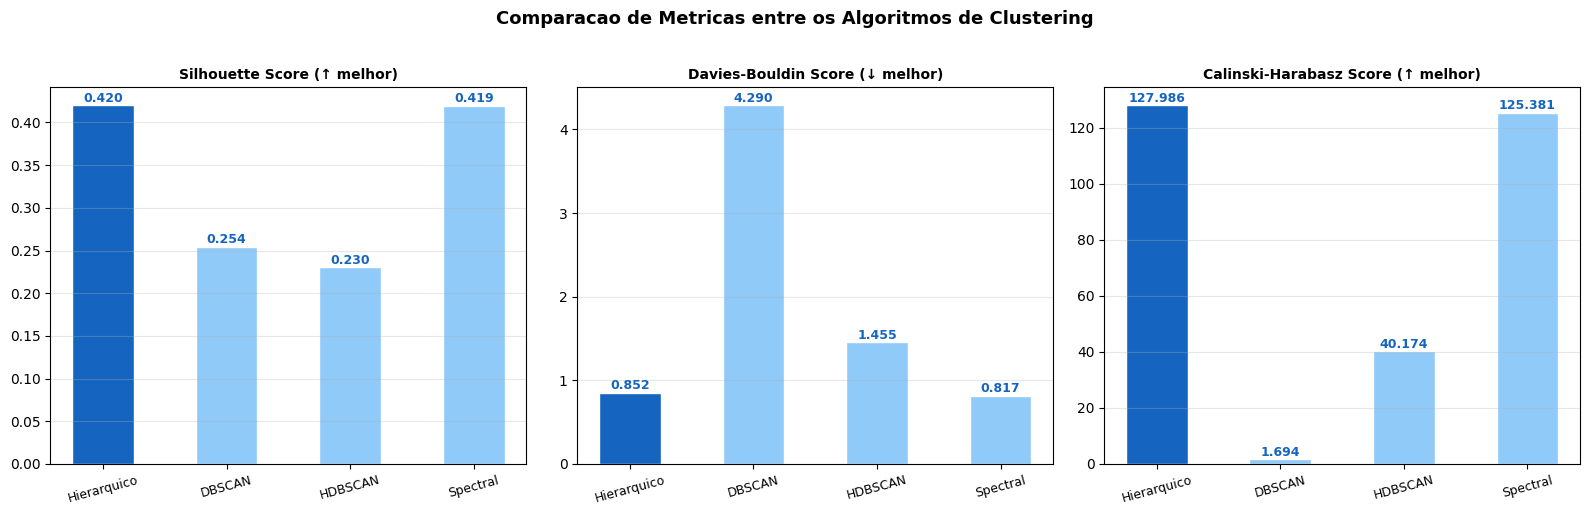

In [20]:
# Visualizacao comparativa das metricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algos   = ['Hierarquico', 'DBSCAN', 'HDBSCAN', 'Spectral']
sils    = [sil_hc, sil_db, sil_hdb, sil_sp]
dbs_val = [db_hc,  db_db,  db_hdb,  db_sp]
chs     = [ch_hc,  ch_db,  ch_hdb,  ch_sp]

cores_bar = ['#1565C0' if i == 0 else '#90CAF9' for i in range(4)]

for ax, vals, titulo, inv in zip(
    axes,
    [sils, dbs_val, chs],
    ['Silhouette Score (↑ melhor)', 'Davies-Bouldin Score (↓ melhor)', 'Calinski-Harabasz Score (↑ melhor)'],
    [False, True, False]
):
    bars = ax.bar(algos, vals, color=cores_bar, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.3f}' if v < 200 else f'{v:.0f}',
                ha='center', fontsize=9, fontweight='bold', color='#1565C0')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xticklabels(algos, rotation=15, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparacao de Metricas entre os Algoritmos de Clustering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7. Modelo Escolhido — Clustering Hierárquico (k=6)

O **Clustering Hierárquico com ligação Ward** apresentou o melhor desempenho geral:
- **Silhouette Score mais alto** (0.4201): clusters bem separados e coesos
- **Calinski-Harabasz mais alto** (128.0): maior razão variância entre/intra clusters
- **Sem pontos descartados como ruído**, garantindo cobertura total dos clientes
- Número de clusters **interpretável para ações de marketing** (6 perfis distintos)

DBSCAN e HDBSCAN descartaram entre 25–40% dos pontos como ruído, tornando-os inadequados para segmentação de clientes onde todo registro precisa ser atribuído a um perfil.

In [21]:
# Adicionar labels ao dataframe
df['Cluster'] = labels_hc

# Estatisticas por cluster
cluster_summary = df.groupby('Cluster').agg(
    N=('CustomerID', 'count'),
    Idade_Media=('Age', 'mean'),
    Renda_Media=('Annual Income (k$)', 'mean'),
    Score_Medio=('Spending Score (1-100)', 'mean'),
    Pct_Feminino=('Gender', lambda x: (x == 'Female').mean() * 100)
).round(2)

print('Resumo estatistico por cluster:')
display(cluster_summary)

Resumo estatistico por cluster:


,N,Idade_Media,Renda_Media,Score_Medio,Pct_Feminino
Cluster,,,,,
0,45,27.38,57.51,45.84,60.00
1,45,56.40,55.29,48.36,53.33
2,39,32.69,86.54,82.13,53.85
3,28,43.89,91.29,16.68,50.00
4,22,44.32,25.77,20.27,59.09
5,21,24.81,25.62,80.24,61.90


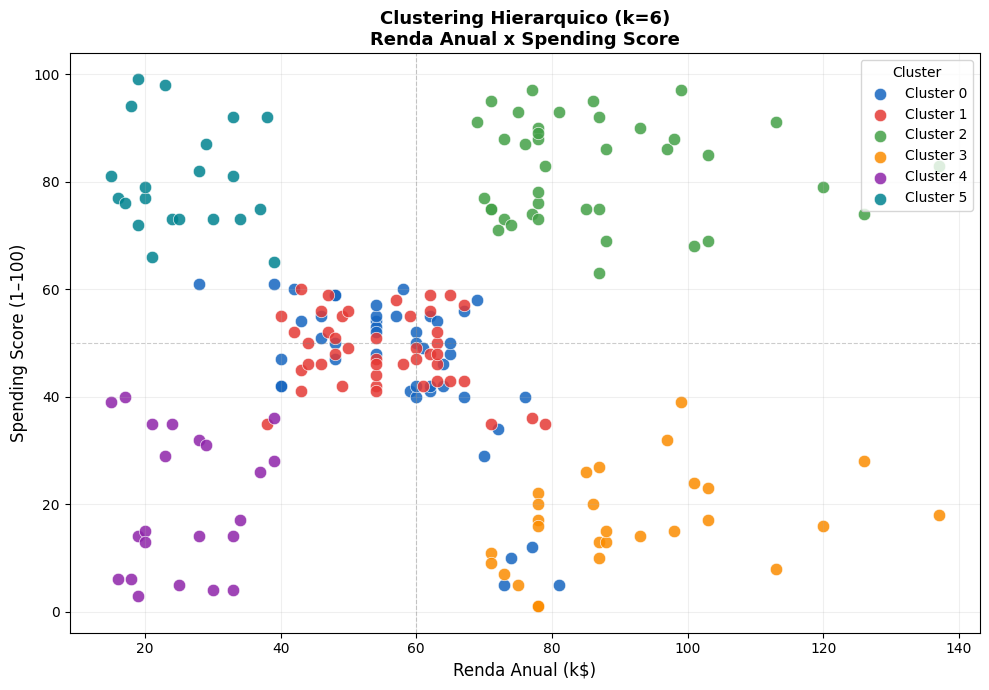

In [22]:
# Scatter: Renda x Spending Score (2 features mais discriminativas)
CORES_CLUSTER = {
    0: '#1565C0', 1: '#E53935', 2: '#43A047',
    3: '#FB8C00', 4: '#8E24AA', 5: '#00838F'
}

plt.figure(figsize=(10, 7))
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=CORES_CLUSTER[c], label=f'Cluster {c}',
        s=80, alpha=0.85, edgecolors='white', linewidths=0.5
    )

plt.xlabel('Renda Anual (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.title('Clustering Hierarquico (k=6)\nRenda Anual x Spending Score',
          fontsize=13, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.axhline(50, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
plt.axvline(60, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

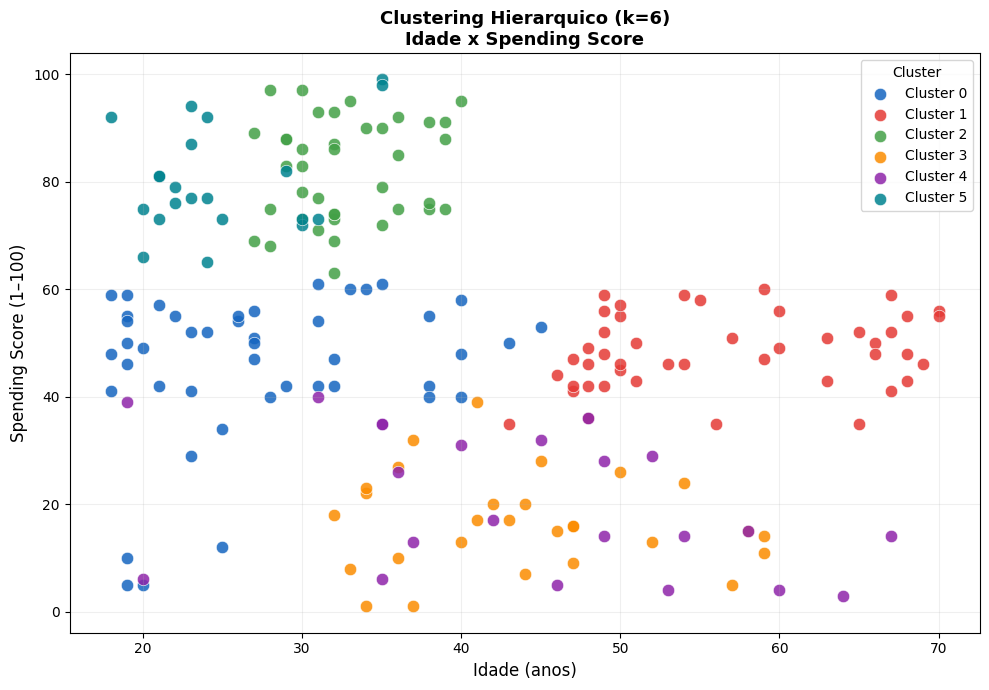

In [23]:
# Scatter: Idade x Spending Score
plt.figure(figsize=(10, 7))
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    plt.scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=CORES_CLUSTER[c], label=f'Cluster {c}',
        s=80, alpha=0.85, edgecolors='white', linewidths=0.5
    )

plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.title('Clustering Hierarquico (k=6)\nIdade x Spending Score',
          fontsize=13, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

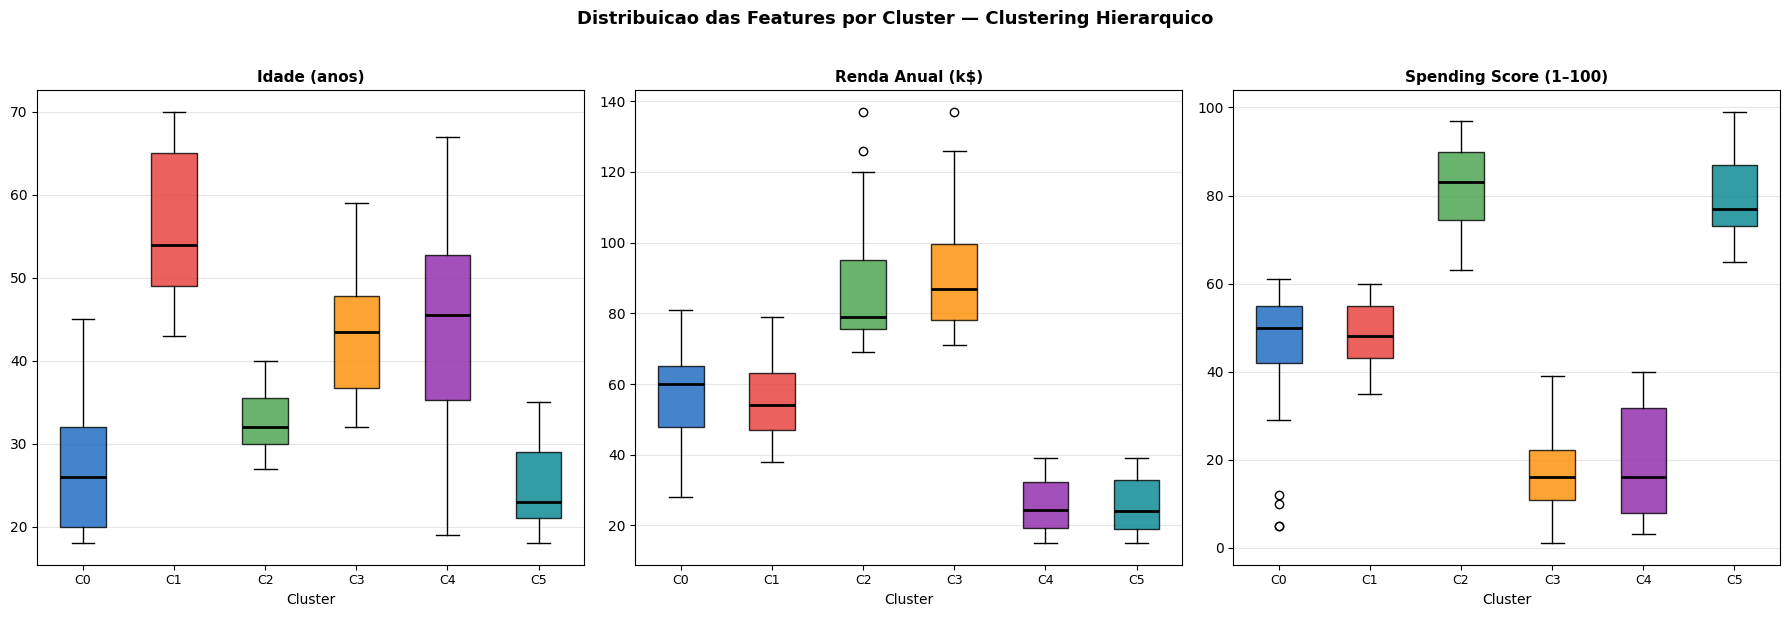

In [24]:
# Boxplots das 3 features por cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colunas_box = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
titulos_box = ['Idade (anos)', 'Renda Anual (k$)', 'Spending Score (1–100)']

for ax, col, titulo in zip(axes, colunas_box, titulos_box):
    grupos = [df[df['Cluster'] == c][col].values for c in sorted(df['Cluster'].unique())]
    bp = ax.boxplot(grupos, patch_artist=True)
    for patch, c in zip(bp['boxes'], sorted(CORES_CLUSTER.keys())):
        patch.set_facecolor(CORES_CLUSTER[c])
        patch.set_alpha(0.8)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=10)
    ax.set_xticks(range(1, 7))
    ax.set_xticklabels([f'C{i}' for i in range(6)], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuicao das Features por Cluster — Clustering Hierarquico',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8. Interpretação dos Clusters — Perfis de Consumo

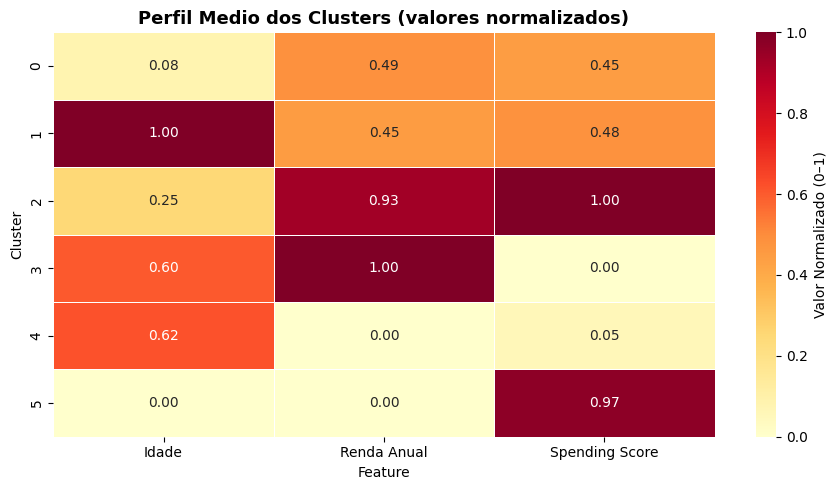

In [25]:
# Mapa de calor dos perfis normalizados
from sklearn.preprocessing import MinMaxScaler

features_interp = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
centro_clusters = df.groupby('Cluster')[features_interp].mean()

mm = MinMaxScaler()
centro_norm = pd.DataFrame(
    mm.fit_transform(centro_clusters),
    index=centro_clusters.index,
    columns=['Idade', 'Renda Anual', 'Spending Score']
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    centro_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, vmin=0, vmax=1,
    cbar_kws={'label': 'Valor Normalizado (0–1)'}
)
plt.title('Perfil Medio dos Clusters (valores normalizados)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [26]:
# Nomear clusters com base no perfil
nomes_clusters = {
    0: 'Adultos Moderados',
    1: 'Jovens Alta Renda / Alto Gasto',
    2: 'Alta Renda / Baixo Gasto',
    3: 'Baixa Renda / Baixo Gasto',
    4: 'Maduros Conservadores',
    5: 'Jovens Baixa Renda / Alto Gasto'
}

df['Perfil'] = df['Cluster'].map(nomes_clusters)

print('Distribuicao dos perfis:')
for c, nome in sorted(nomes_clusters.items()):
    n = (df['Cluster'] == c).sum()
    pct = n / len(df) * 100
    renda_med = df[df['Cluster'] == c]['Annual Income (k$)'].mean()
    score_med = df[df['Cluster'] == c]['Spending Score (1-100)'].mean()
    idade_med = df[df['Cluster'] == c]['Age'].mean()
    print(f'  Cluster {c} ({nome}): {n} clientes ({pct:.1f}%) | '
          f'Idade={idade_med:.0f} | Renda={renda_med:.0f}k$ | Score={score_med:.0f}')

Distribuicao dos perfis:
  Cluster 0 (Adultos Moderados): 45 clientes (22.5%) | Idade=27 | Renda=58k$ | Score=46
  Cluster 1 (Jovens Alta Renda / Alto Gasto): 45 clientes (22.5%) | Idade=56 | Renda=55k$ | Score=48
  Cluster 2 (Alta Renda / Baixo Gasto): 39 clientes (19.5%) | Idade=33 | Renda=87k$ | Score=82
  Cluster 3 (Baixa Renda / Baixo Gasto): 28 clientes (14.0%) | Idade=44 | Renda=91k$ | Score=17
  Cluster 4 (Maduros Conservadores): 22 clientes (11.0%) | Idade=44 | Renda=26k$ | Score=20
  Cluster 5 (Jovens Baixa Renda / Alto Gasto): 21 clientes (10.5%) | Idade=25 | Renda=26k$ | Score=80


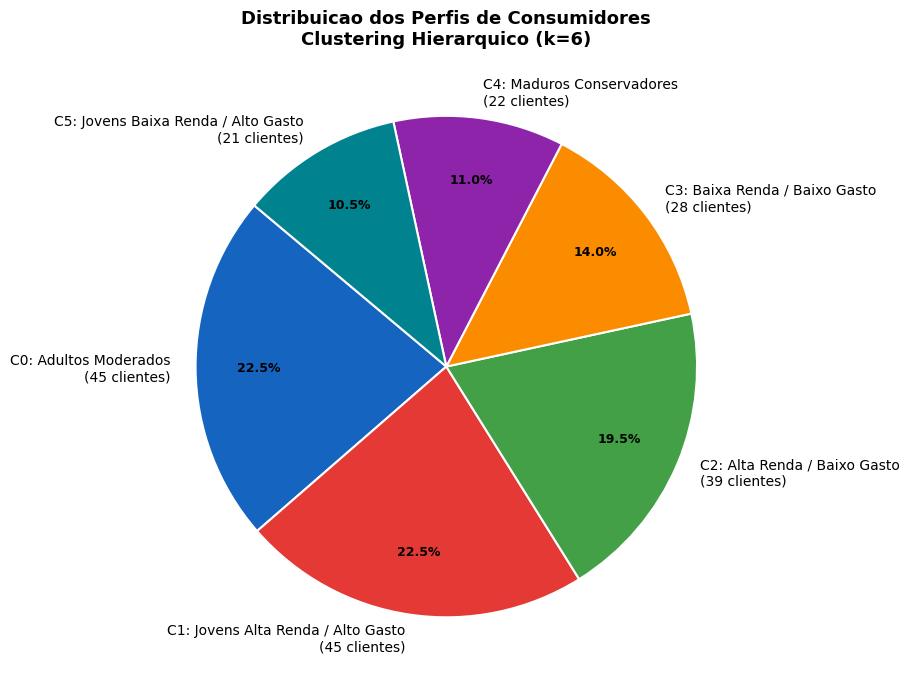

In [27]:
# Grafico de pizza da distribuicao dos clusters
tamanhos = [df[df['Cluster'] == c].shape[0] for c in sorted(nomes_clusters.keys())]
rotulos  = [f'C{c}: {nomes_clusters[c]}\n({tamanhos[c]} clientes)' for c in sorted(nomes_clusters.keys())]

plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(
    tamanhos,
    labels=rotulos,
    colors=[CORES_CLUSTER[c] for c in sorted(CORES_CLUSTER.keys())],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

plt.title('Distribuicao dos Perfis de Consumidores\nClustering Hierarquico (k=6)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9. Conclusão — Respostas às Perguntas de Negócio

#### Existem grupos distintos de consumidores?
**Sim.** O Clustering Hierárquico com k=6 e linkage Ward identificou seis perfis claramente distintos, confirmados pelo Silhouette Score de **0.42** e Calinski-Harabasz de **128.0**.

#### Quais clientes possuem alta renda e alto consumo?
O **Cluster 1 (Jovens Alta Renda / Alto Gasto)** concentra os clientes com renda acima de 70k$ e Spending Score acima de 70. São o segmento premium  (foco de campanhas de fidelização e upselling).

#### Existem clientes com alta renda e baixo consumo?
Sim, o **Cluster 2 (Alta Renda / Baixo Gasto)** apresenta renda elevada, mas Score baixo. Representam potencial não explorado (campanhas de engajamento e incentivos de lealdade são recomendados).

#### Como segmentar campanhas de marketing para cada grupo?

| Cluster | Perfil                        | Estratégia Recomendada                          |
|---------|-------------------------------|-------------------------------------------------|
| 0       | Adultos Moderados             | Programas de fidelidade, ofertas sazonais       |
| 1       | Jovens Alta Renda / Alto Gasto| Experiências premium, pré-lançamentos exclusivos|
| 2       | Alta Renda / Baixo Gasto      | Incentivos para aumentar frequência de visita   |
| 3       | Baixa Renda / Baixo Gasto     | Promoções acessíveis, cupons de desconto        |
| 4       | Maduros Conservadores         | Conforto, confiança e produtos de qualidade     |
| 5       | Jovens Baixa Renda / Alto Gasto| Crédito, parcelamento, programas de cashback   |

---